In [5]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

In [7]:
from tensorflow.keras.callbacks import EarlyStopping

In [8]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [9]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [10]:
X = df['review']
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train size:",len(X_train))
print("Test size:",len(X_test))

Train size: 40000
Test size: 10000


In [11]:
# Tokenization step (MISSING STEP)
vocab_size = 10000
max_length = 200
tokenizer = Tokenizer(num_words=vocab_size)
# Learn vocabulary
tokenizer.fit_on_texts(X_train)
# Convert text to integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
print("Tokenization done")

Tokenization done


In [12]:
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)
print(X_train_pad.shape)
print(X_test_pad.shape)

(40000, 200)
(10000, 200)


In [13]:
model = Sequential()
model.add(Embedding(vocab_size, 128, input_length=max_length))
model.add(SimpleRNN(64, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

C:\Users\23adsb84\.conda\envs\61782323110084\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [34]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=50,
    callbacks=[early_stop],
    batch_size=64
)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.8479 - loss: 0.3558 - val_accuracy: 0.7986 - val_loss: 0.4715
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.9270 - loss: 0.1935 - val_accuracy: 0.8204 - val_loss: 0.4661
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.9611 - loss: 0.1092 - val_accuracy: 0.8322 - val_loss: 0.5574
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.9789 - loss: 0.0613 - val_accuracy: 0.7846 - val_loss: 0.7893
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.9762 - loss: 0.0676 - val_accuracy: 0.7199 - val_loss: 0.7505


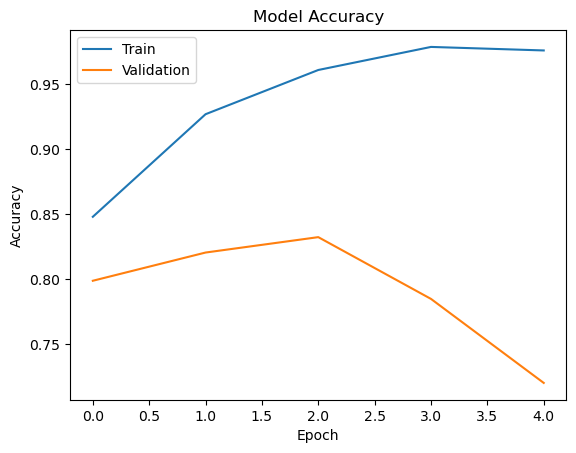

In [35]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])
plt.show()

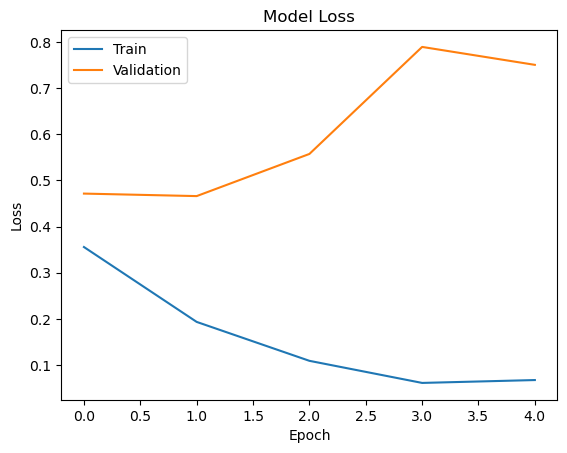

In [36]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])
plt.show()

In [37]:
test_loss, test_acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:",test_acc)
print("Test Loss:",test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7988 - loss: 0.4641
Test Accuracy: 0.798799991607666
Test Loss: 0.4641120135784149


In [38]:
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


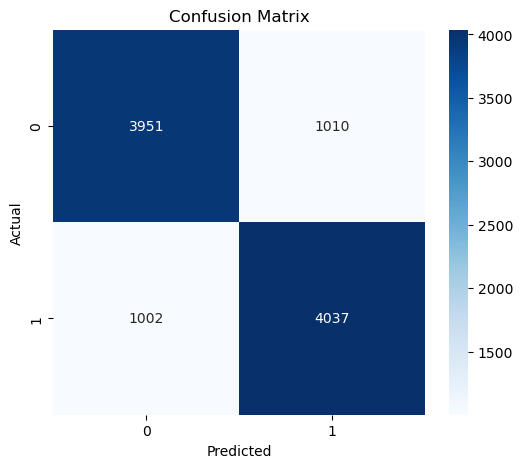

In [39]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [40]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)
print("\nClassification Report\n")
print(classification_report(y_test,y_pred))

Precision: 0.7998811174955419
Recall: 0.8011510220281802
F1 Score: 0.8005155661312711

Classification Report

              precision    recall  f1-score   support

           0       0.80      0.80      0.80      4961
           1       0.80      0.80      0.80      5039

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



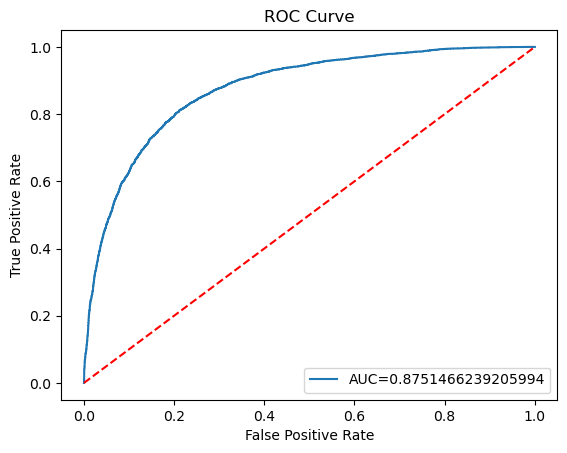

In [41]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr,tpr)
plt.plot(fpr, tpr, label="AUC="+str(roc_auc))
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [42]:
print("Final Evaluation Metrics")
print("------------------------")
print("Test Accuracy:",test_acc)
print("Test Loss:",test_loss)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)
print("AUC:",roc_auc)

Final Evaluation Metrics
------------------------
Test Accuracy: 0.798799991607666
Test Loss: 0.4641120135784149
Precision: 0.7998811174955419
Recall: 0.8011510220281802
F1 Score: 0.8005155661312711
AUC: 0.8751466239205994
